In [270]:
import pandas as pd
import numpy as np

import math
import matplotlib.pyplot as plt
import seaborn as sns

In [122]:
data = pd.read_csv("Telco-Customer-Churn.csv") 

In [124]:
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [126]:
data.shape

(7043, 21)

In [128]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [130]:
for item in data.columns:
    print(f"Unique {item}'s count: {data[item].nunique()}")
    print(f"{data[item].unique()}")

Unique customerID's count: 7043
['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']
Unique gender's count: 2
['Female' 'Male']
Unique SeniorCitizen's count: 2
[0 1]
Unique Partner's count: 2
['Yes' 'No']
Unique Dependents's count: 2
['No' 'Yes']
Unique tenure's count: 73
[ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]
Unique PhoneService's count: 2
['No' 'Yes']
Unique MultipleLines's count: 3
['No phone service' 'No' 'Yes']
Unique InternetService's count: 3
['DSL' 'Fiber optic' 'No']
Unique OnlineSecurity's count: 3
['No' 'Yes' 'No internet service']
Unique OnlineBackup's count: 3
['Yes' 'No' 'No internet service']
Unique DeviceProtection's count: 3
['No' 'Yes' 'No internet service']
Unique TechSupport's count: 3
['No' 'Yes' 'No internet service']
Unique StreamingTV's count: 3
['N

In [132]:
data.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [134]:
# Converting numerical data to int64/float64
data["tenure"] = data["tenure"].astype("int64")
data["MonthlyCharges"] = data["MonthlyCharges"].astype("float64")

In [136]:
data["TotalCharges"].sample(40) # Discovered null values under Total Charges column but was not detected 

1042     1046.5
6931    5720.95
452      3582.4
298     3015.75
4344     5330.2
6504      267.6
4869     1248.9
685        49.9
6609       20.1
1926    4872.45
4918    1086.75
7010      74.45
6756     1938.9
2335     274.35
4541      50.55
386      4874.7
107      927.65
6488       69.5
2812       6890
2628       83.4
2834      854.9
150      564.35
3900      708.8
852          62
2486    2509.25
4698     5265.1
4312     2603.1
3877    1157.05
4105     7009.5
2349    6565.85
1597    4473.45
2662      90.35
81       565.35
93         7107
3950    4718.25
1284    1188.25
4921     3767.4
6274    4939.25
6127    6109.65
3962     646.85
Name: TotalCharges, dtype: object

In [138]:
tot_charges_null = data[data["TotalCharges"].str.strip() == ""]
tot_charges_null

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [140]:
data = data.drop(index = tot_charges_null.index)

In [142]:
data["TotalCharges"] = data["TotalCharges"].astype("float64")

In [144]:
data.shape

(7032, 21)

In [146]:
# Converting categorical data 
cat_data = ["gender", "SeniorCitizen", "Partner", "Dependents", "PhoneService", "MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup", 
"DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies", "Contract", "PaperlessBilling", "PaymentMethod", "Churn"]
 
data[cat_data] = data[cat_data].astype("category")

In [148]:
data.dtypes

customerID            object
gender              category
SeniorCitizen       category
Partner             category
Dependents          category
tenure                 int64
PhoneService        category
MultipleLines       category
InternetService     category
OnlineSecurity      category
OnlineBackup        category
DeviceProtection    category
TechSupport         category
StreamingTV         category
StreamingMovies     category
Contract            category
PaperlessBilling    category
PaymentMethod       category
MonthlyCharges       float64
TotalCharges         float64
Churn               category
dtype: object

In [150]:
convert_data = ["MultipleLines", "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"]
data[convert_data] = (data[convert_data].astype(str).replace({"No internet service": "No","No phone service": "No"}).astype("category"))

In [152]:
data[convert_data].nunique()

MultipleLines       2
OnlineSecurity      2
OnlineBackup        2
DeviceProtection    2
TechSupport         2
StreamingTV         2
StreamingMovies     2
dtype: int64

In [157]:
data["SeniorCitizen"] = (data["SeniorCitizen"].astype(str).replace({"1" : "Yes", "0": "No"}).astype("category"))

In [161]:
data["SeniorCitizen"].sample(5)

894     No
3129    No
3520    No
3591    No
1440    No
Name: SeniorCitizen, dtype: category
Categories (2, object): ['No', 'Yes']

### Exploratory Data Analysis

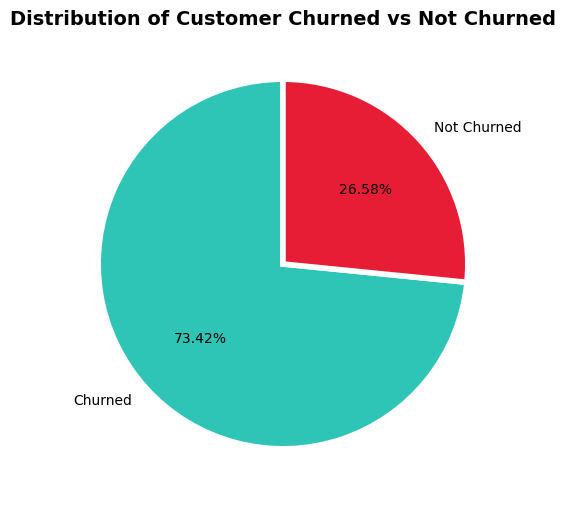

In [181]:
# Distribution of Churn & Not Churn 

class_counts = data["Churn"].value_counts()

colors = ["#2ec4b6", "#e71d36"]

plt.figure(figsize=(10,6))
plt.pie(
    class_counts,
    labels = ["Churned", "Not Churned"],
    autopct = "%1.2f%%", 
    startangle=90,
    colors=colors, 
    wedgeprops = {"edgecolor": "white", "linewidth": 4}
)

plt.title("Distribution of Customer Churned vs Not Churned", fontsize = 14, fontweight = "bold")
plt.show()

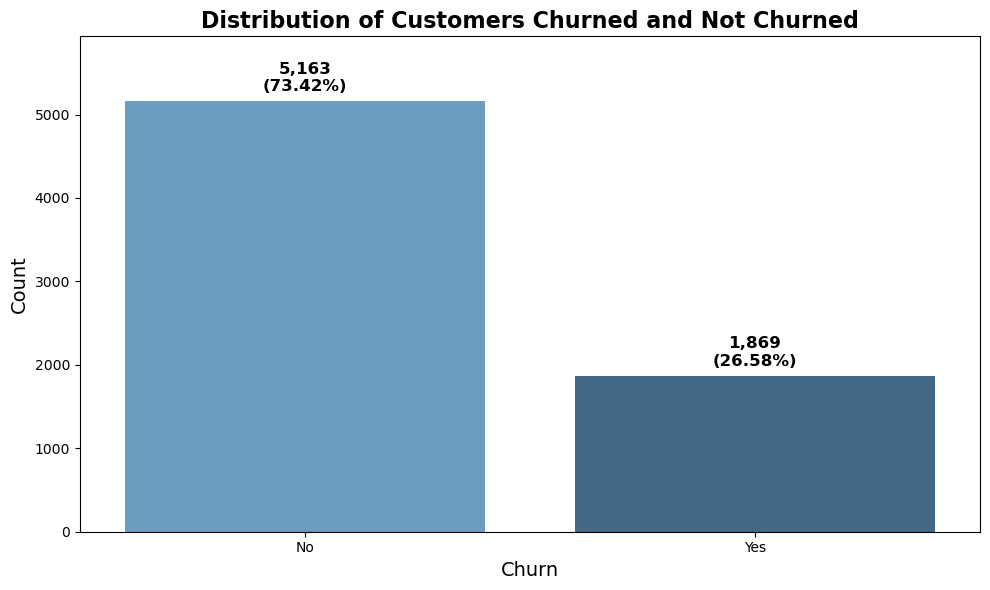

In [187]:
plt.figure(figsize = (10,6))
ax = sns.countplot(data = data, x = "Churn", hue = "Churn", palette = "Blues_d", legend = False)

total = len(data)
for p in ax.patches: 
    height = p.get_height()
    percentage = f"{100 * height / total:.2f}%"
    ax.annotate(
        f"{int(height):,}\n({percentage})",
        (p.get_x() + p.get_width() / 2.0, height),
        ha = "center", 
        va = "bottom",
        fontsize = 12, 
        fontweight = "bold", 
        xytext = (0,5),
        textcoords = "offset points")

ax.set_ylim(0, max([p.get_height() for p in ax.patches]) * 1.15)

plt.title("Distribution of Customers Churned and Not Churned", fontsize = 16, fontweight = "bold")
plt.ylabel("Count", fontsize = 14)
plt.xlabel("Churn", fontsize = 14)
plt.tight_layout()
plt.show()

/var/folders/g5/dytxyb0j79z2kyyt76ppcfbm0000gn/T/ipykernel_1258/1420278718.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = data, y = "tenure", palette = "Blues_d", legend = False)


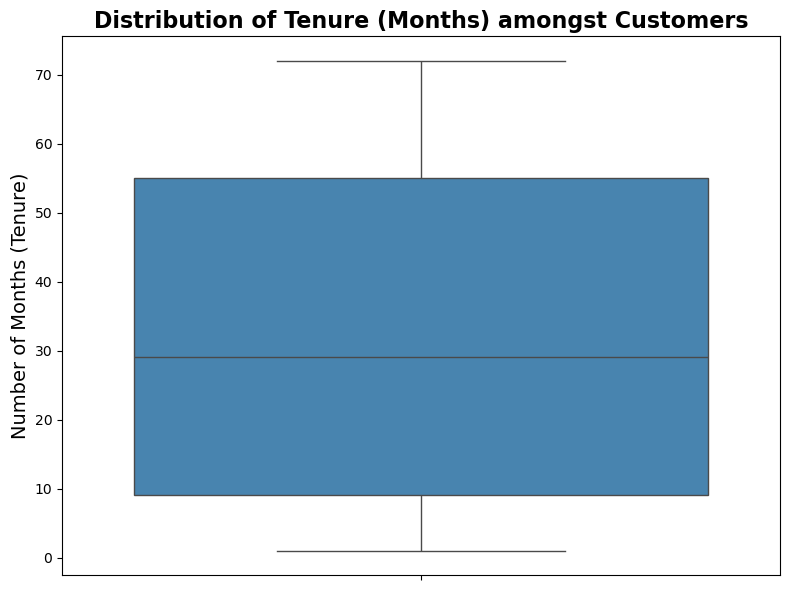

In [209]:
# Distribution of Tenure amongst Customers 
plt.figure(figsize = (8, 6))
sns.boxplot(data = data, y = "tenure", palette = "Blues_d", legend = False)
plt.title("Distribution of Tenure (Months) amongst Customers", fontsize = 16, fontweight = "bold")
plt.ylabel("Number of Months (Tenure)", fontsize = 14)
plt.tight_layout()
plt.show()

/var/folders/g5/dytxyb0j79z2kyyt76ppcfbm0000gn/T/ipykernel_1258/3090540878.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = data, y = "MonthlyCharges", palette = "Blues_d", legend = False)


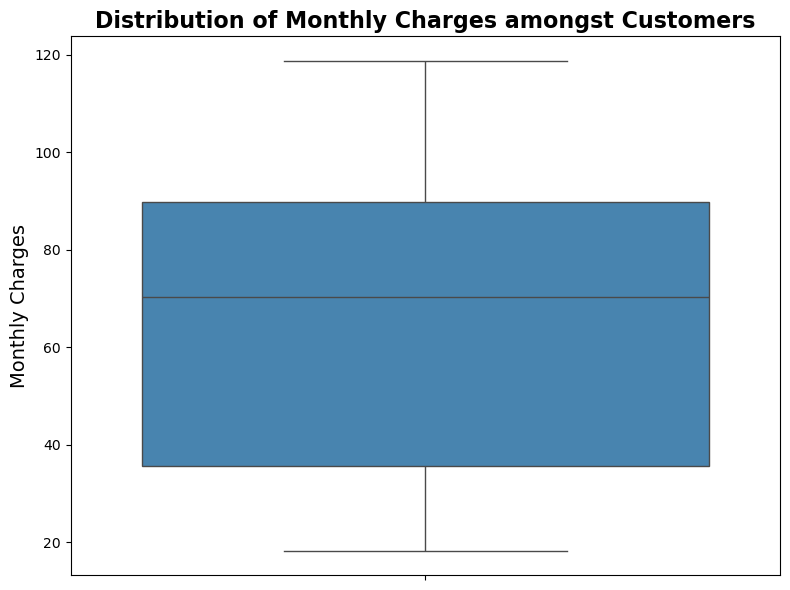

In [217]:
# Distribution of Monthly Charges amongst Customers 
plt.figure(figsize = (8, 6))
sns.boxplot(data = data, y = "MonthlyCharges", palette = "Blues_d", legend = False)
plt.title("Distribution of Monthly Charges amongst Customers", fontsize = 16, fontweight = "bold")
plt.ylabel("Monthly Charges", fontsize = 14)
plt.tight_layout()
plt.show()

/var/folders/g5/dytxyb0j79z2kyyt76ppcfbm0000gn/T/ipykernel_1258/3703056568.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = data, y = "TotalCharges", palette = "Blues_d", legend = False)


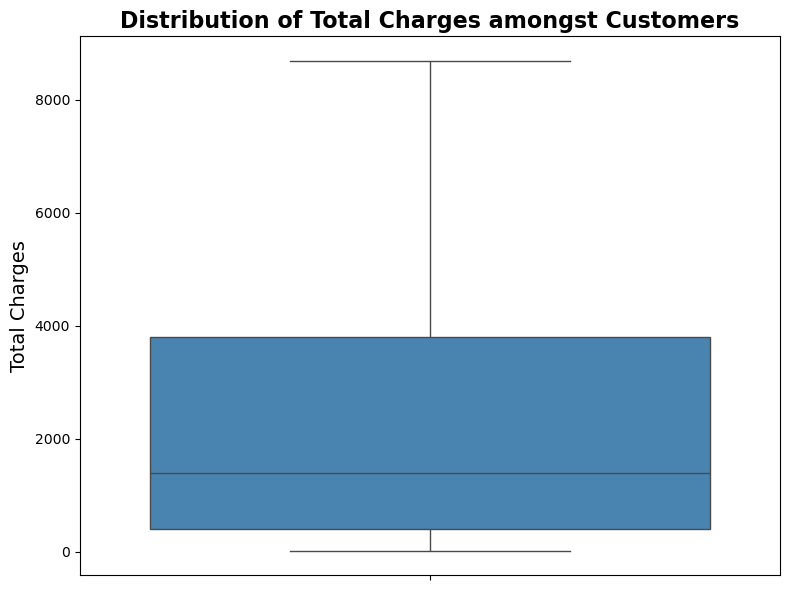

In [219]:
# Distribution of Total Charges amongst Customers 
plt.figure(figsize = (8, 6))
sns.boxplot(data = data, y = "TotalCharges", palette = "Blues_d", legend = False)
plt.title("Distribution of Total Charges amongst Customers", fontsize = 16, fontweight = "bold")
plt.ylabel("Total Charges", fontsize = 14)
plt.tight_layout()
plt.show()

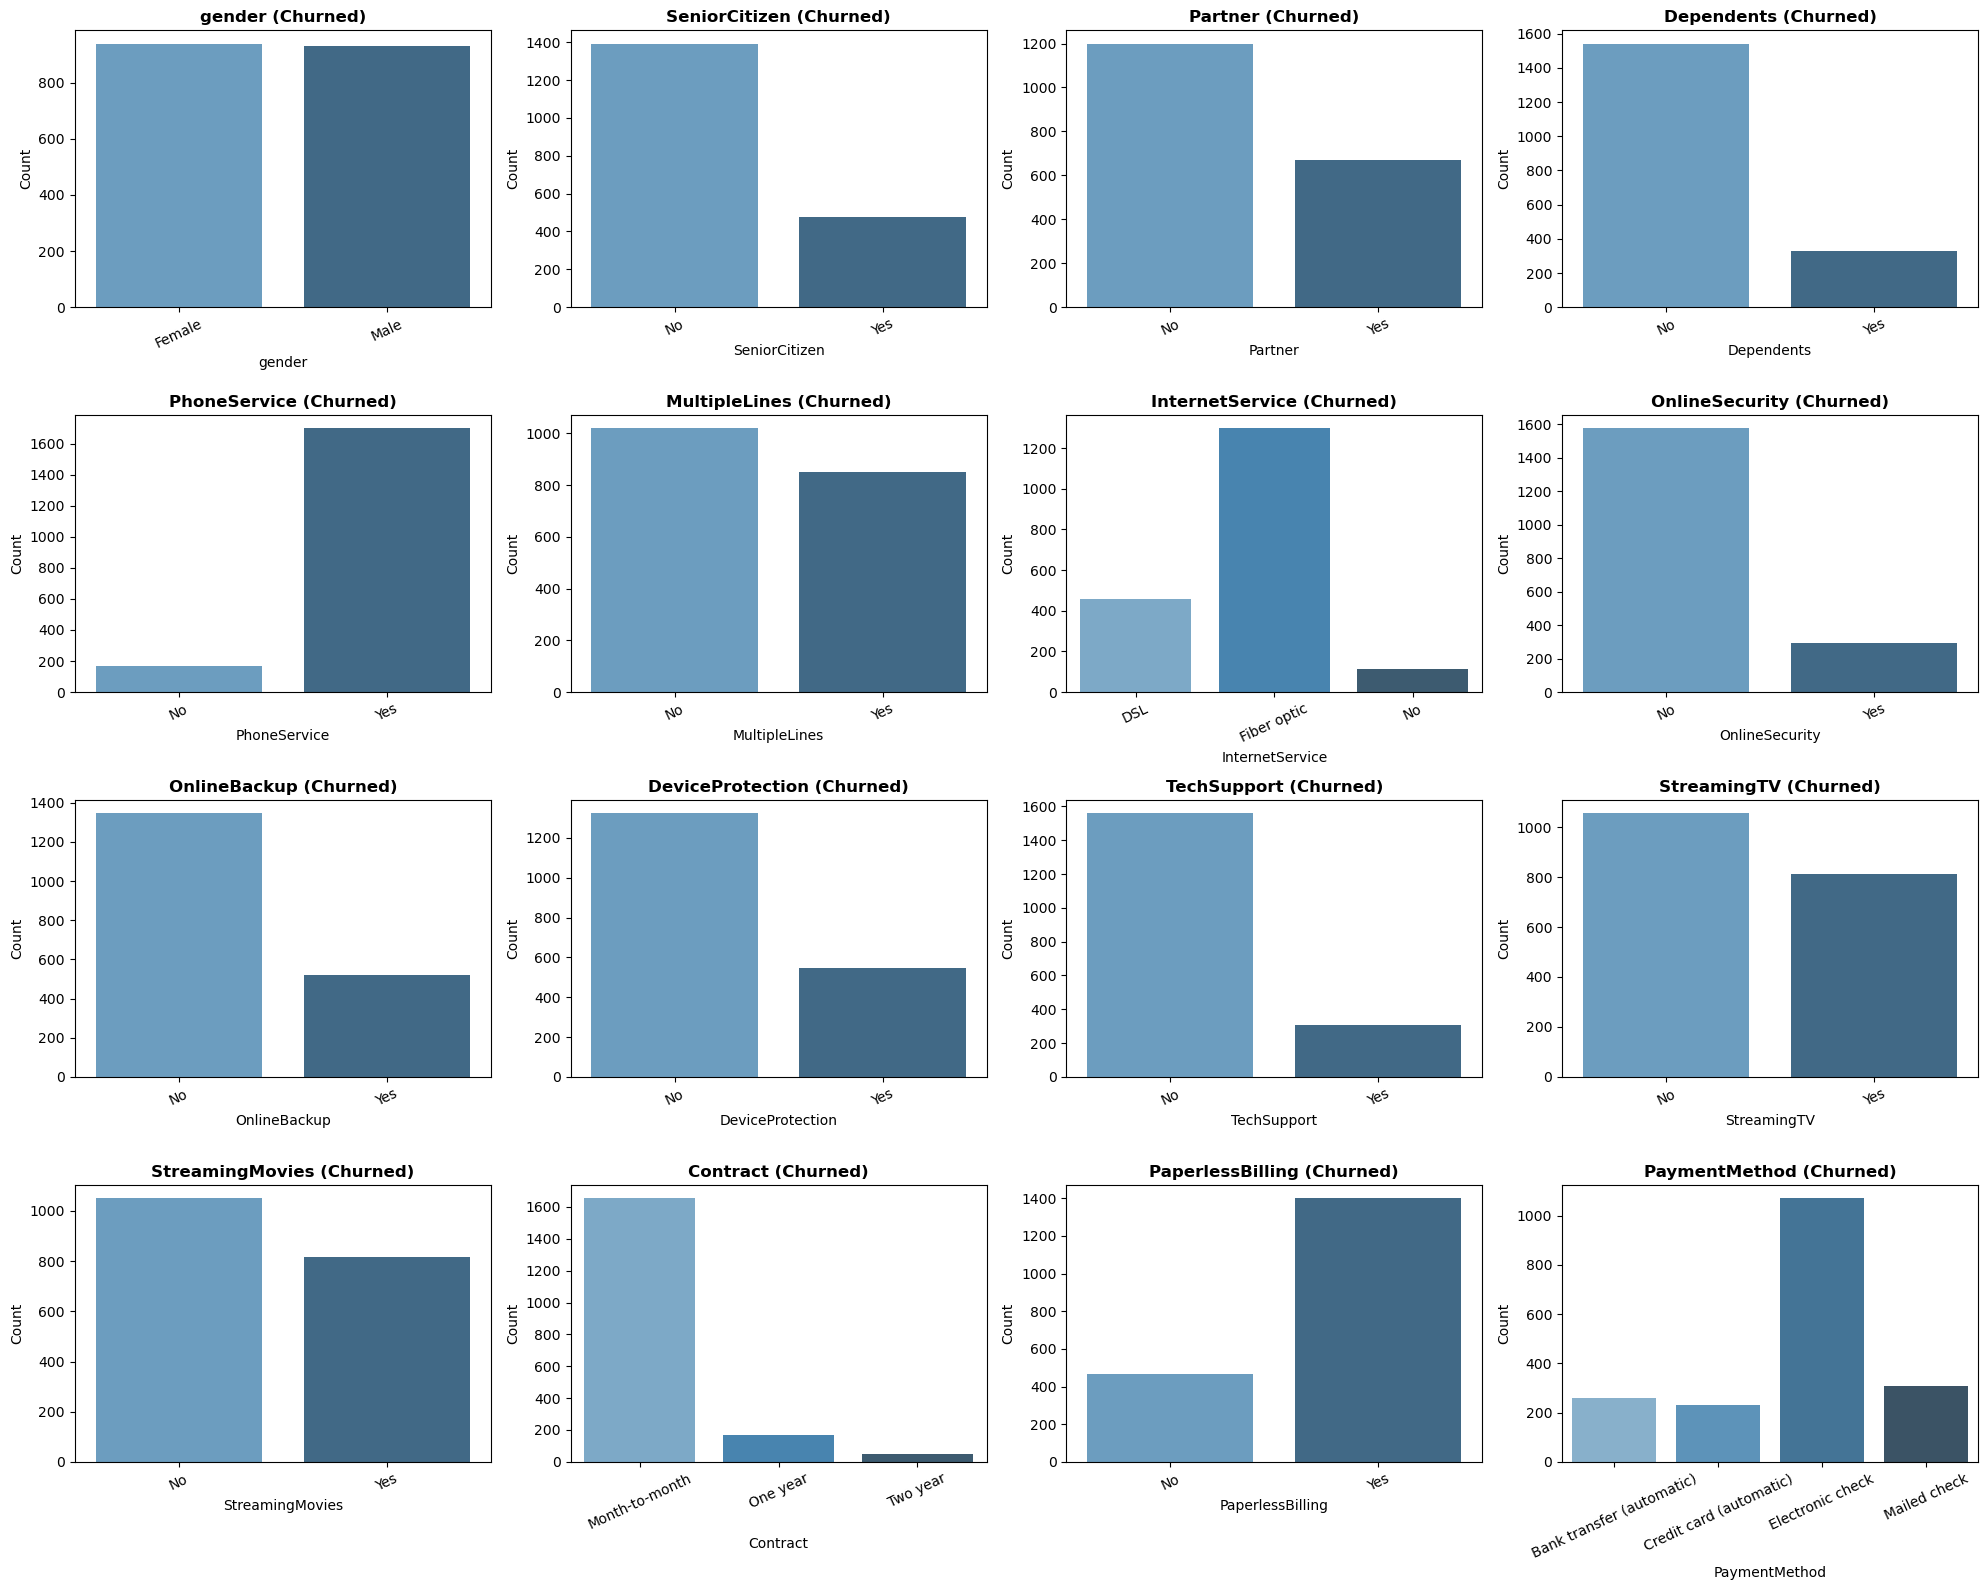

In [276]:
churned_cust = data[data["Churn"] == "Yes"]

exclude_cols = ["customerID", "MonthlyCharges", "TotalCharges", "tenure"]
cols_to_plot = [col for col in churned_cust.columns if col not in exclude_cols and col != "Churn"]

n_cols = 4
n_rows = math.ceil(len(cols_to_plot) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    sns.countplot(
        data=churned_cust, 
        x=col, 
        hue=col, 
        ax=axes[i], 
        palette="Blues_d", 
        legend=False
    )
    axes[i].set_title(f"{col} (Churned)", fontweight="bold")
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis="x", rotation=25)

for j in range(len(cols_to_plot), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

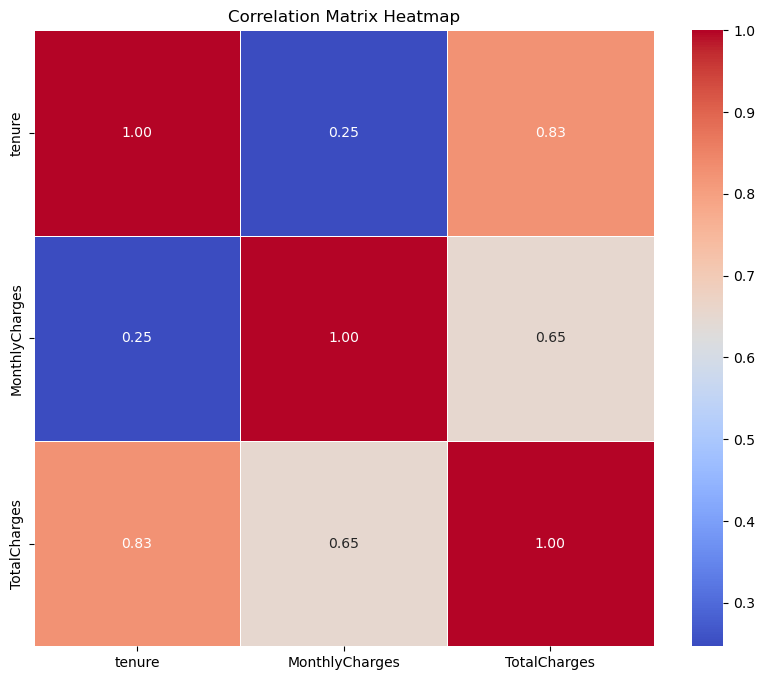

In [223]:
cols_to_include = ["tenure", "MonthlyCharges", "TotalCharges"]
corr_matrix = data[cols_to_include].corr()

plt.figure(figsize = (1,8))
sns.heatmap(corr_matrix, cmap = "coolwarm", annot = True, fmt = ".2f", linewidth = 0.5)
plt.title("Correlation Matrix Heatmap")
plt.show()

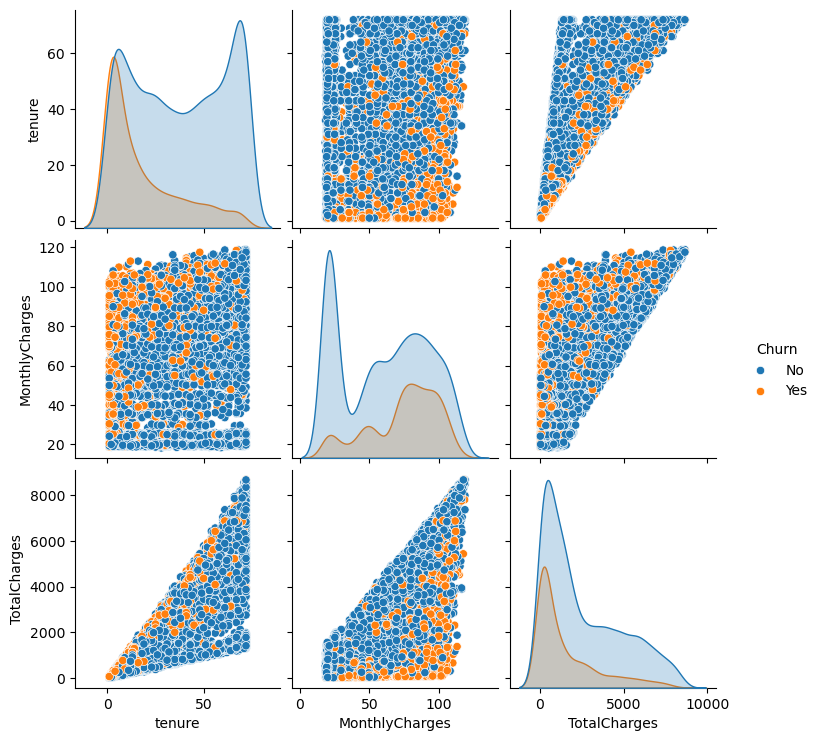

In [229]:
sns.pairplot(data[cols_to_include+["Churn"]], hue="Churn")